# IN5437 — Assignment 1
## Question 1: Intensity Transformations on the Runway Image

**Name:** Benjamine  
**Index:** 258762Q

- (a) Apply gamma correction to the L plane in the L*a*b* color space and state the γ value.
- (b) Show the histograms of the original and corrected images.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read the image in color (BGR) from the images folder
q2_im_bgr = cv.imread('../images/highlights_and_shadows.jpg')
assert q2_im_bgr is not None, "File could not be read. Check the path."
print('Shape:', q2_im_bgr.shape, '| Dtype:', q2_im_bgr.dtype)

Shape: (480, 720, 3) | Dtype: uint8


### Question 02.a: Gamma correction on the L channel

Convert BGR → L * a * b *, apply gamma correction only to the L channel, then merge back.

In [3]:
# Convert BGR → L*a*b* and split into L, a, b channels
q2_im_lab = cv.cvtColor(q2_im_bgr, cv.COLOR_BGR2LAB)
L, a, b = cv.split(q2_im_lab)
print('L range:', L.min(), '-', L.max(), '| Mean:', round(float(L.mean()), 2))

L range: 0 - 255 | Mean: 71.26


In [4]:
# Build the gamma LUT and apply only to the L channel
gamma_2 = 0.6
t_2 = np.array([((i/255.0) ** gamma_2) * 255 for i in np.arange(0, 256)]).astype(np.uint8)

L_corrected = cv.LUT(L, t_2)
print(f'γ used: {gamma_2}')
print(f'L mean before: {L.mean():.2f}  |  L mean after: {L_corrected.mean():.2f}')

γ used: 0.6
L mean before: 71.26  |  L mean after: 104.24


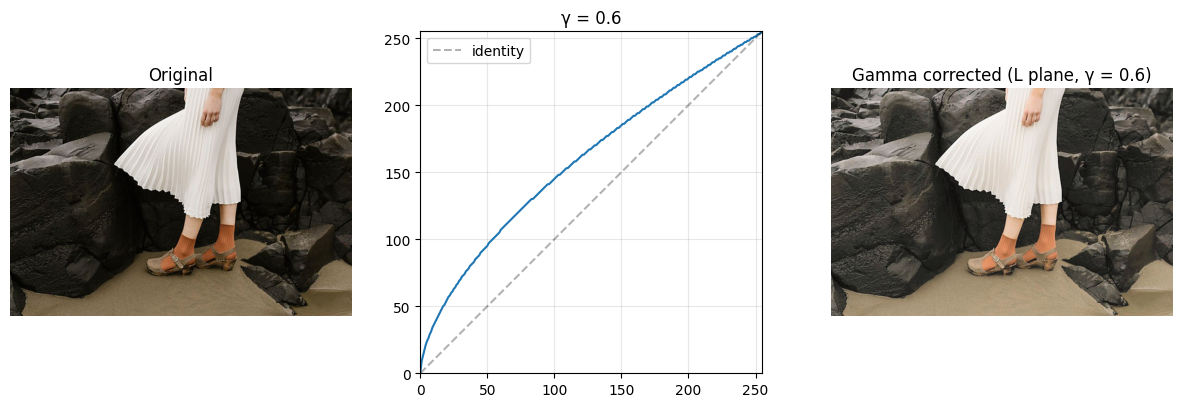

In [5]:
# Merge corrected L with original a, b, then convert back to BGR
q2_im_lab_corrected = cv.merge([L_corrected, a, b])
q2_im_bgr_corrected = cv.cvtColor(q2_im_lab_corrected, cv.COLOR_LAB2BGR)

# Convert both to RGB for matplotlib display
q2_im_rgb_original  = cv.cvtColor(q2_im_bgr, cv.COLOR_BGR2RGB)
q2_im_rgb_corrected = cv.cvtColor(q2_im_bgr_corrected, cv.COLOR_BGR2RGB)

# Display: original | gamma curve | corrected
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(q2_im_rgb_original); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].plot(np.arange(256), t_2); ax[1].plot([0,255],[0,255],'k--',alpha=0.3,label='identity')
ax[1].set_xlim(0,255); ax[1].set_ylim(0,255); ax[1].set_title(f'γ = {gamma_2}'); ax[1].grid(alpha=0.3); ax[1].set_aspect('equal'); ax[1].legend()
ax[2].imshow(q2_im_rgb_corrected); ax[2].set_title(f'Gamma corrected (L plane, γ = {gamma_2})'); ax[2].axis('off')
plt.show()

### Question 02.b: Histograms of the original and corrected images

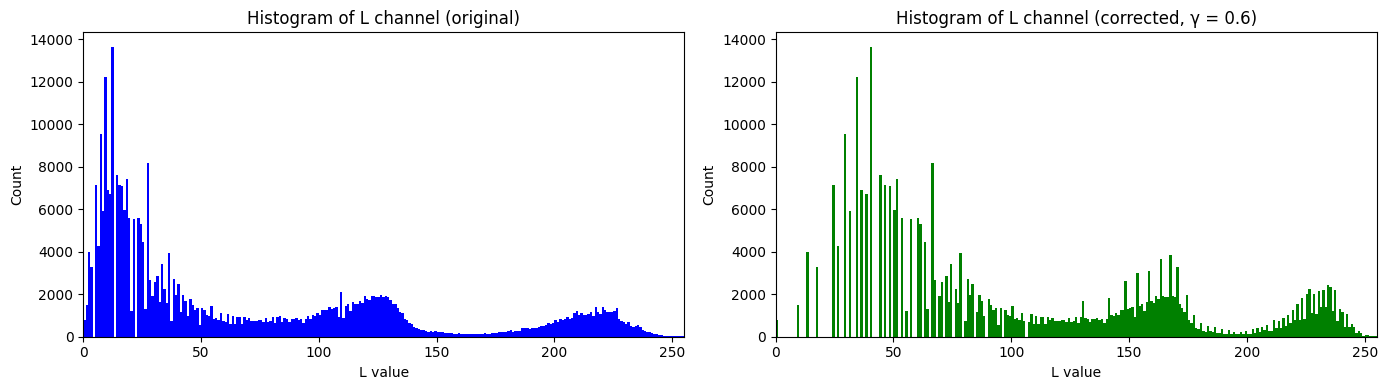

In [6]:
# Histograms of the L channel: original vs corrected
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(L.ravel(), bins=256, range=(0,256), color='blue')
ax[0].set_xlim(0, 255)
ax[0].set_title('Histogram of L channel (original)')
ax[0].set_xlabel('L value'); ax[0].set_ylabel('Count')

ax[1].hist(L_corrected.ravel(), bins=256, range=(0,256), color='green')
ax[1].set_xlim(0, 255)
ax[1].set_title(f'Histogram of L channel (corrected, γ = {gamma_2})')
ax[1].set_xlabel('L value'); ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

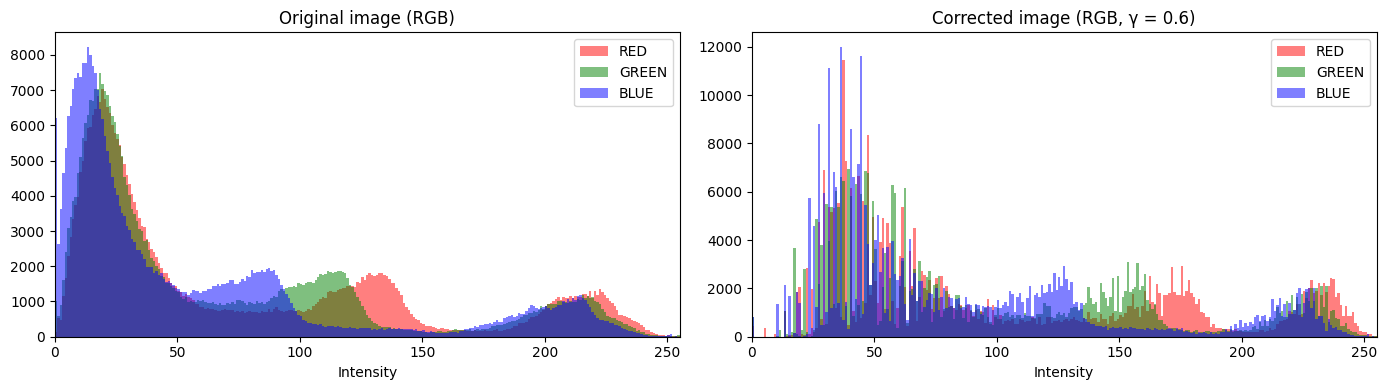

In [7]:
# Full-image RGB histograms: original vs corrected
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

for img, title, a_ in zip(
    [q2_im_rgb_original, q2_im_rgb_corrected],
    ['Original image (RGB)', f'Corrected image (RGB, γ = {gamma_2})'],
    ax
):
    for ch, color in enumerate(['red', 'green', 'blue']):
        a_.hist(img[:, :, ch].ravel(), bins=256, range=(0,256),
                color=color, alpha=0.5, label=color.upper())
    a_.set_xlim(0, 255); a_.set_title(title); a_.set_xlabel('Intensity'); a_.legend()

plt.tight_layout()
plt.show()